In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']=(12,5)
plt.rcParams['figure.dpi']=100
df=pd.read_excel('../Online Retail.xlsx')

print("Shape:",df.shape)
print("\nColumn names:",df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (541909, 8)

Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
missing=pd.DataFrame({
    'Missing count': df.isnull().sum(),
    'Missing %': (df.isnull().sum()/len(df)*100).round(2)
})
print(missing[missing['Missing count']>0])

             Missing count  Missing %
Description           1454       0.27
CustomerID          135080      24.93


In [9]:
print(df.describe())

print("\nUnique values:")
print("Invoices:",df['InvoiceNo'].nunique())
print("Products:",df['StockCode'].nunique())
print("Customers:",df['CustomerID'].nunique())
print("Countries:",df['Country'].nunique)

cancelled=df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"\nCancelled Orders: {len(cancelled)} ({len(cancelled)/len(df)*100:.1f}%)")

            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.000000  
std      1713.600303  

Unique values:
Invoices: 25900
Products: 4070
Customers: 4372
Countries: <bound method IndexOpsMixin.nunique of 0         United Kingdom
1         United Kingdom

In [10]:
print("Negative Quantity rows:",(df['Quantity']<0).sum())
print("Negative UnitPrice rows:",(df['UnitPrice']<0).sum())
print("Zero UnitPrice rows:",(df['UnitPrice']==0).sum())

Negative Quantity rows: 10624
Negative UnitPrice rows: 2
Zero UnitPrice rows: 2515


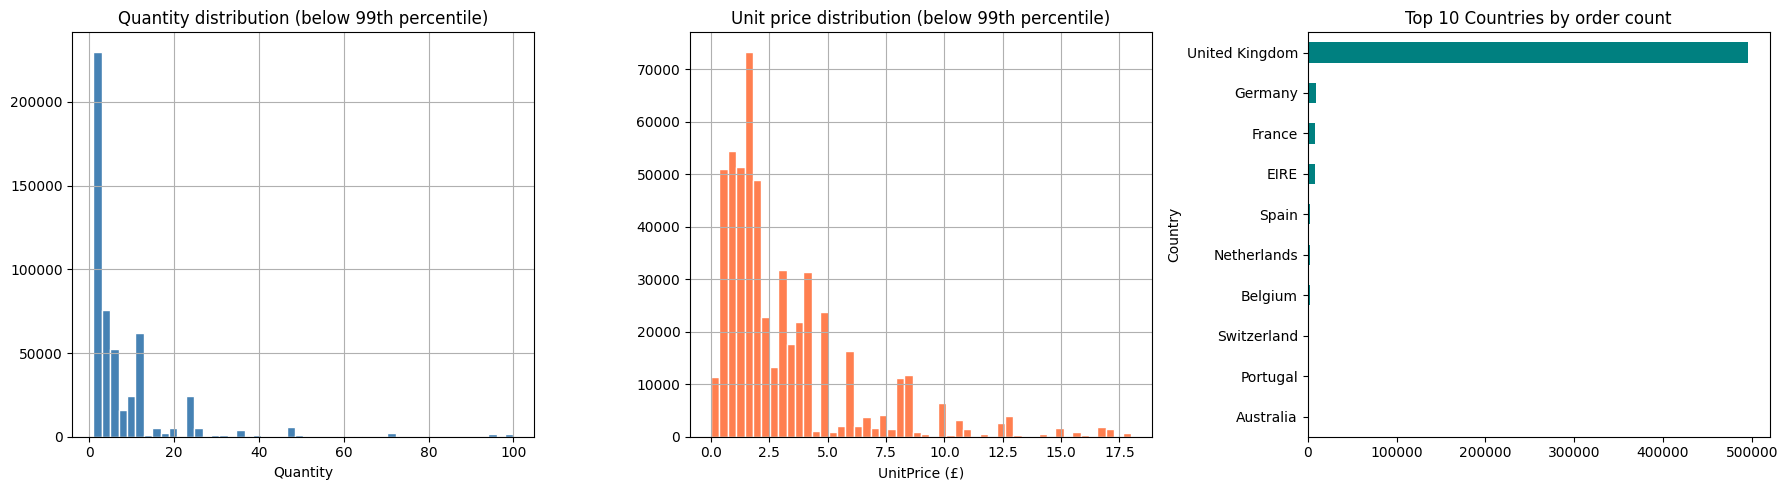

In [11]:
fig,axes=plt.subplots(1,3,figsize=(18,5))

#Quantity distribution (cap at 99th percentile for readability)
q99=df['Quantity'].quantile(0.99)
df[df['Quantity'].between(0,q99)]['Quantity'].hist(
    bins=50, ax=axes[0], color='steelblue',edgecolor='white'
)
axes[0].set_title('Quantity distribution (below 99th percentile)')
axes[0].set_xlabel('Quantity')

#UnitPrice distribution
p99=df['UnitPrice'].quantile(0.99)
df[df['UnitPrice'].between(0,p99)]['UnitPrice'].hist(
    bins=50,ax=axes[1],color='coral',edgecolor='white'
)
axes[1].set_title("Unit price distribution (below 99th percentile)")
axes[1].set_xlabel('UnitPrice (£)')

top_countries=df['Country'].value_counts().head(10)
top_countries.plot(kind='barh',ax=axes[2],color='teal')
axes[2].set_title("Top 10 Countries by order count")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/univariate_analysis.png',dpi=100,bbox_inches='tight')
plt.show()


In [12]:
#Top 10 products by revenue
df['Revenue']=df['Quantity']*df['UnitPrice']

top_products=(
    df[df['Revenue']>0]
    .groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

print("Top 10 Products by revenue:\n",top_products)

Top 10 Products by revenue:
 Description
PADS TO MATCH ALL CUSHIONS             0.003
HEN HOUSE W CHICK IN NEST              0.420
SET 12 COLOURING PENCILS DOILEY        0.650
VINTAGE BLUE TINSEL REEL               0.840
PINK CRYSTAL GUITAR PHONE CHARM        0.850
HAPPY BIRTHDAY CARD TEDDY/CAKE         0.950
CAT WITH SUNGLASSES BLANK CARD         0.950
60 GOLD AND SILVER FAIRY CAKE CASES    1.100
PACK 4 FLOWER/BUTTERFLY PATCHES        1.250
ORANGE FELT VASE + FLOWERS             1.250
Name: Revenue, dtype: float64


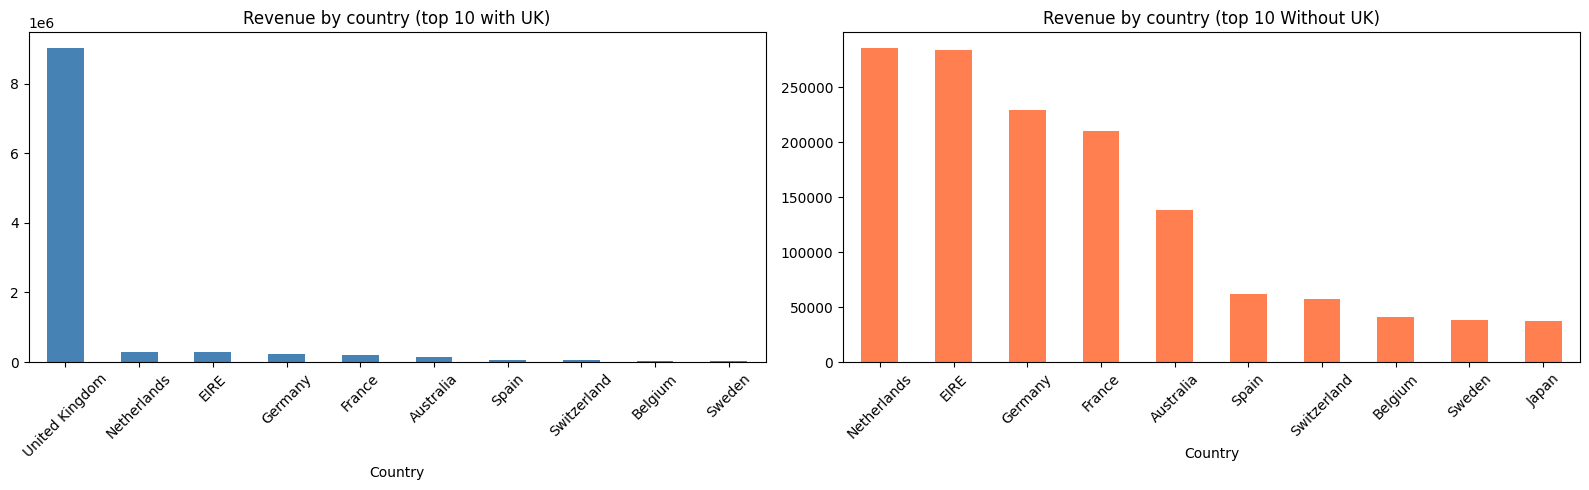

In [13]:
#Revenue by country (excluding UK, top 10)
revenue_by_country=(
    df[df['Revenue']>0]
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

fig,axes=plt.subplots(1,2,figsize=(16,5))

#With UK
revenue_by_country.head(10).plot(kind='bar',ax=axes[0], color='steelblue')
axes[0].set_title("Revenue by country (top 10 with UK)")
axes[0].tick_params(axis='x', rotation=45)

#Without UK
revenue_by_country.drop('United Kingdom',errors='ignore').head(10).plot(
    kind='bar',ax=axes[1],color='coral'
)

axes[1].set_title("Revenue by country (top 10 Without UK)")
axes[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.savefig('../outputs/revenue_by_country.png',dpi=100, bbox_inches='tight')
plt.show()

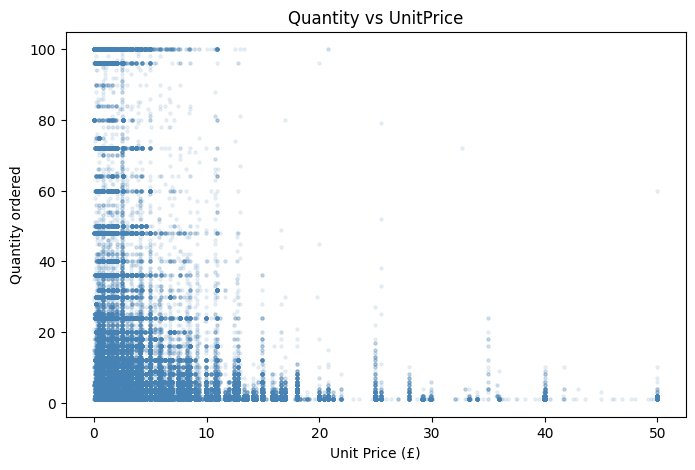

Correlation (Quantity vs UnitPrice): -0.004


In [15]:
#Correlation between Quantity and UnitPrice

clean=df[(df['Quantity']>0) & (df['UnitPrice']>0)].copy()

plt.figure(figsize=(8,5))
plt.scatter(
    clean['UnitPrice'].clip(upper=50),
    clean['Quantity'].clip(upper=100),
    alpha=0.1, color='steelblue',s=5
)

plt.xlabel("Unit Price (£)")
plt.ylabel("Quantity ordered")
plt.title("Quantity vs UnitPrice")
plt.savefig('../outputs/qty_vs_price.png',dpi=100,bbox_inches='tight')
plt.show()

print("Correlation (Quantity vs UnitPrice):", clean[['Quantity','UnitPrice']].corr().iloc[0,1].round(3))

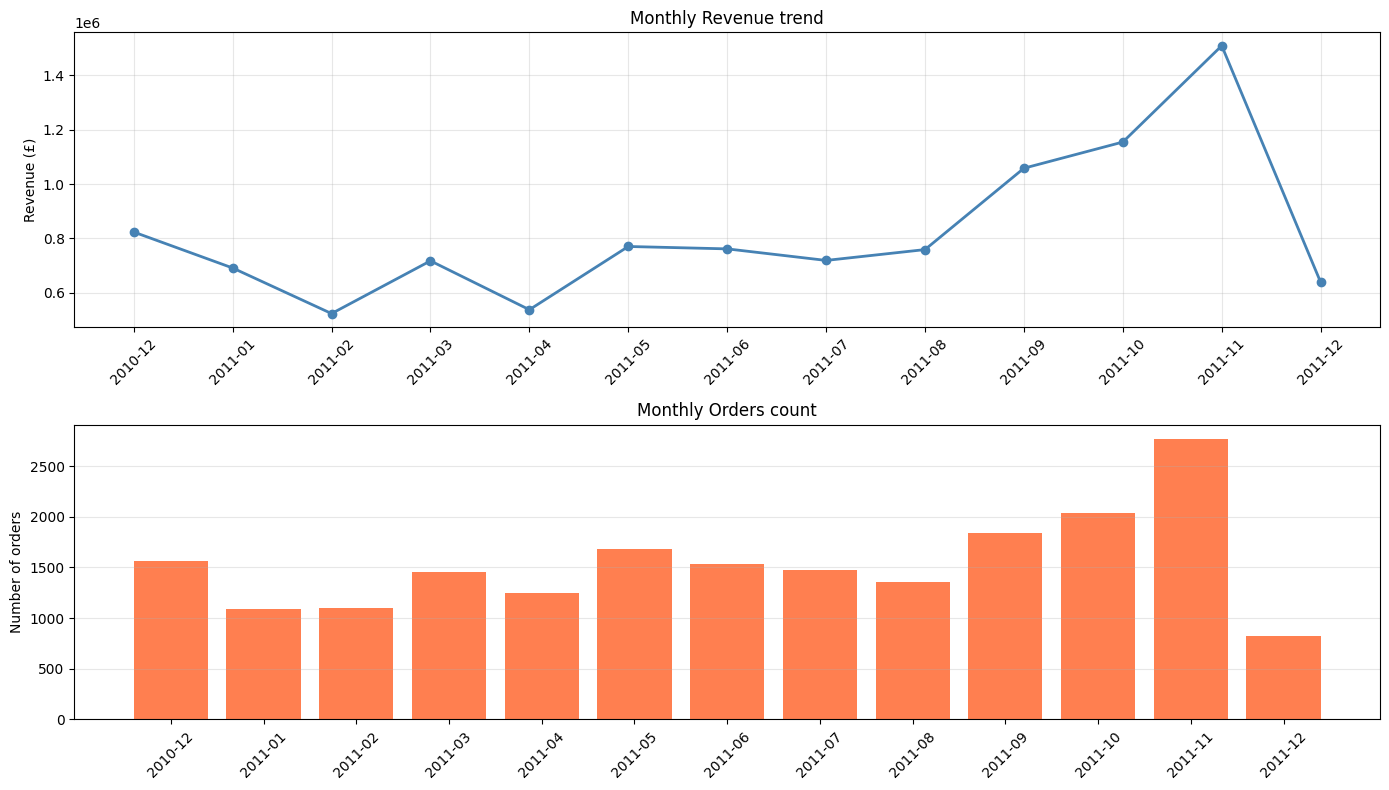

In [19]:
#Parse InvoiceDate
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['YearMonth']=df['InvoiceDate'].dt.to_period('M')

#Monthly revenue trend
monthly_revenue=(
    df[df['Revenue']>0].groupby('YearMonth')['Revenue'].sum().reset_index()
)
monthly_revenue['YearMonth_str']=monthly_revenue['YearMonth'].astype(str)

fig,axes=plt.subplots(2,1,figsize=(14,8))

#Revenue trend
axes[0].plot(
    monthly_revenue['YearMonth_str'],
    monthly_revenue['Revenue'],
    marker='o', color='steelblue', linewidth=2
)

axes[0].set_title("Monthly Revenue trend")
axes[0].set_ylabel("Revenue (£)")
axes[0].tick_params(axis='x',rotation=45)
axes[0].grid(alpha=0.3)

#Monthly order count
monthly_orders=(
    df[df['Revenue']>0].groupby('YearMonth')['InvoiceNo'].nunique().reset_index()
)
monthly_orders['YearMonth_str']=monthly_orders['YearMonth'].astype(str)

axes[1].bar(
    monthly_orders['YearMonth_str'],
    monthly_orders['InvoiceNo'],
    color='coral'
)

axes[1].set_title("Monthly Orders count")
axes[1].set_ylabel("Number of orders")
axes[1].tick_params(axis='x',rotation=45)
axes[1].grid(alpha=0.3,axis='y')

plt.tight_layout()
plt.savefig('../outputs/time_series_analysis.png',dpi=100,bbox_inches='tight')
plt.show()



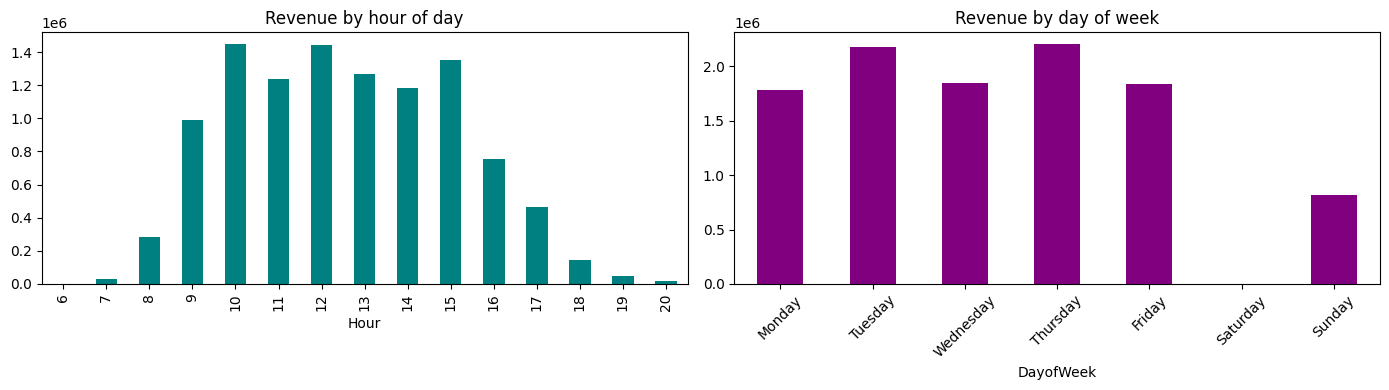

In [21]:
#Peak hour analysis
df['Hour']=df['InvoiceDate'].dt.hour
df['DayofWeek']=df['InvoiceDate'].dt.day_name()

hourly=df[df['Revenue']>0].groupby('Hour')['Revenue'].sum()
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily=(
    df[df['Revenue']>0].groupby('DayofWeek')['Revenue'].sum().reindex(day_order)
)

fig,axes=plt.subplots(1,2,figsize=(14,4))
hourly.plot(kind='bar',color='teal',ax=axes[0])
axes[0].set_title("Revenue by hour of day")
axes[0].set_xlabel("Hour")

daily.plot(kind='bar',color='purple',ax=axes[1])
axes[1].set_title("Revenue by day of week")
axes[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.savefig('../outputs/peak_times.png',dpi=100,bbox_inches='tight')
plt.show()